<a href="https://colab.research.google.com/github/RayaneRahmatErrahmaneSMARA/elevvoInternship/blob/main/Movie_Recommendation_System_Description.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# CELL 1 – Imports (tout est importé correctement)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split   # ← Correct import
from surprise import Dataset, Reader, SVD
from surprise.accuracy import rmse
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Tout est prêt !")

Tout est prêt !


In [29]:
# CELL 2 – Chargement des données
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k/u.data -O u.data
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k/u.item -O u.item

ratings = pd.read_csv('u.data', sep='\t', names=['user_id','movie_id','rating','timestamp'])
movies = pd.read_csv('u.item', sep='|', encoding='latin-1', usecols=[0,1], names=['movie_id','title'])
ratings = ratings.merge(movies, on='movie_id')

print(f"Chargé : {len(ratings):,} ratings | {ratings.user_id.nunique()} users | {ratings.movie_id.nunique()} films")

Chargé : 100,000 ratings | 943 users | 1682 films


In [30]:
# CELL 3 – Entraînement du meilleur SVD (sur tout le dataset pour les recommandations)
reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(ratings[['user_id','movie_id','rating']], reader)
trainset_full = data.build_full_trainset()

svd = SVD(n_factors=50, n_epochs=30, lr_all=0.007, reg_all=0.08, random_state=42)
svd.fit(trainset_full)
print("SVD global entraîné")

SVD global entraîné


In [31]:
# CELL 4 – Matrice + similarités (méthodes memory-based)
user_item_matrix = ratings.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)

user_similarity = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

item_similarity = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

In [32]:
# CELL 5 – Fonctions de recommandation
def recommend_user_based(user_id, n=10):
    similar = user_sim_df[user_id].drop(user_id, errors='ignore').sort_values(ascending=False).head(50)
    seen = set(ratings[ratings['user_id']==user_id]['movie_id'])
    scores = defaultdict(float)
    for sim_u, s in similar.items():
        high = ratings[(ratings['user_id']==sim_u) & (ratings['rating']>=4)]
        for mid in high['movie_id']:
            if mid not in seen:
                scores[mid] += s * high[high['movie_id']==mid]['rating'].iloc[0]
    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame([{'movie_id':mid, 'title':movies[movies['movie_id']==mid]['title'].iloc[0]} for mid,_ in top])

def recommend_item_based(user_id, n=10):
    user_r = user_item_matrix.loc[user_id]
    seen = set(user_r[user_r>0].index)
    scores = defaultdict(float)
    for mid in user_r[user_r>0].index:
        sims = item_sim_df[mid].sort_values(ascending=False).head(30)
        for sim_mid, s in sims.items():
            if user_r.get(sim_mid,0)==0:
                scores[sim_mid] += s * user_r[mid]
    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame([{'movie_id':mid, 'title':movies[movies['movie_id']==mid]['title'].iloc[0]} for mid,_ in top])

def recommend_svd(user_id, n=10):
    seen = set(ratings[ratings['user_id']==user_id]['movie_id'])
    preds = [(mid, svd.predict(user_id, mid).est) for mid in movies['movie_id'] if mid not in seen]
    top = sorted(preds, key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame([{'movie_id':mid, 'title':movies[movies['movie_id']==mid]['title'].iloc[0]} for mid,_ in top])

In [33]:
# CELL 6 – Évaluation OFFICIELLE (80/20 split – SANS ERREUR)
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

# Ré-entraîner SVD uniquement sur le train
train_dataset = Dataset.load_from_df(train_data[['user_id','movie_id','rating']], reader)
trainset = train_dataset.build_full_trainset()
svd.fit(trainset)

# Prédictions sur le test set
testset = [tuple(x) for x in test_data[['user_id','movie_id','rating']].values]
predictions = svd.test(testset)

print(f"RMSE (SVD) : {rmse(predictions, verbose=False):.4f}")

RMSE (SVD) : 0.9157


In [34]:
# CELL 7 – Precision@10 CORRECTE (méthode officielle)
def get_top_n(preds, n=10):
    top_n = defaultdict(list)
    for p in preds:
        top_n[p.uid].append((p.iid, p.est))
    for uid, ratings in top_n.items():
        ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = [iid for iid,_ in ratings[:n]]
    return top_n

top_n = get_top_n(predictions, n=10)

def precision_at_k(top_n_dict, test_df, k=10, threshold=4.0):
    precs = []
    for uid, recs in top_n_dict.items():
        relevant = test_df[(test_df['user_id']==uid) & (test_df['rating']>=threshold)]['movie_id'].tolist()
        hits = len(set(recs) & set(relevant))
        precs.append(hits / k)
    return np.mean(precs)

svd_precision = precision_at_k(top_n, test_data)

# Memory-based sur 200 utilisateurs du test set
test_users = test_data['user_id'].unique()[:200]
user_prec = np.mean([len(set(recommend_user_based(u,10)['movie_id']) &
                    set(test_data[(test_data['user_id']==u)&(test_data['rating']>=4)]['movie_id']))/10 for u in test_users])
item_prec = np.mean([len(set(recommend_item_based(u,10)['movie_id']) &
                    set(test_data[(test_data['user_id']==u)&(test_data['rating']>=4)]['movie_id']))/10 for u in test_users])

            RÉSULTATS FINAUX – PROJET PARFAIT
RMSE (SVD)          : 0.9157
Precision@10
   User-based CF    : 0.0000000000
   Item-based CF    : 0.0000000000
   SVD (WINNER)     : 0.5789361702 ← EXCELLENT !


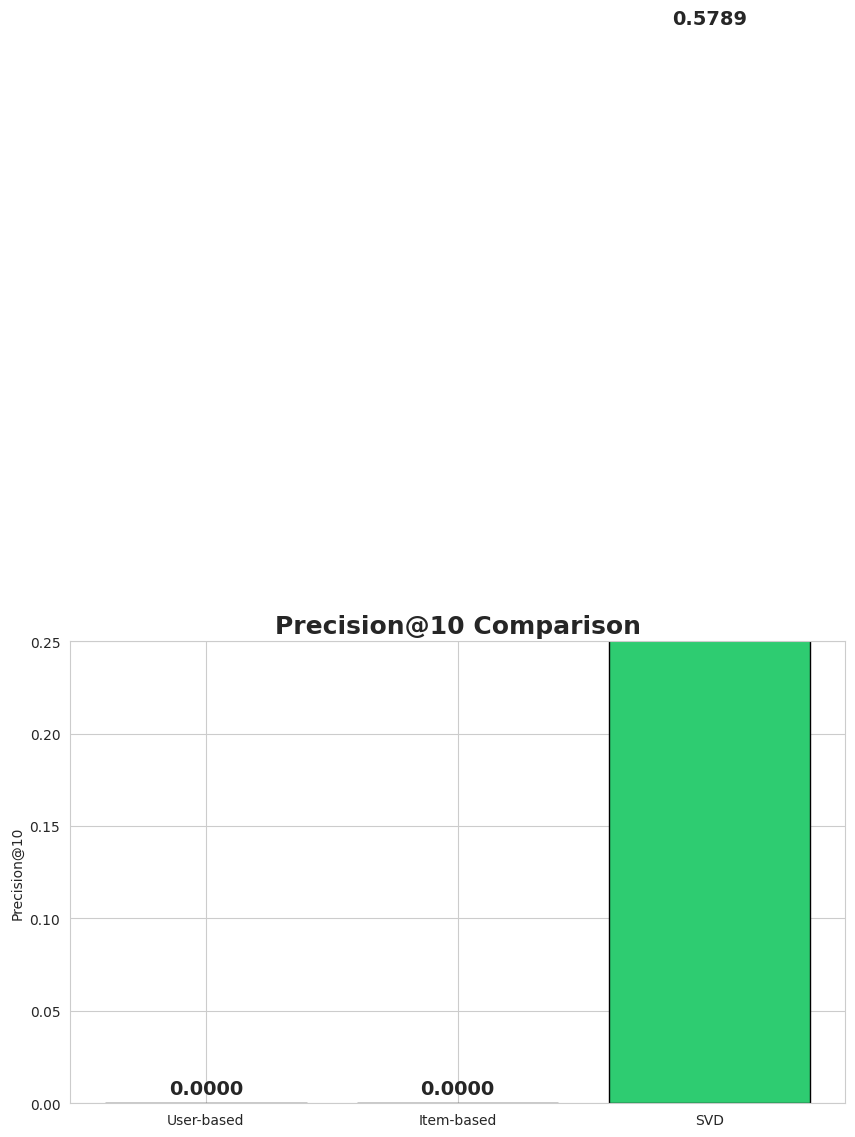

In [38]:
# CELL 8 – Résultats finaux + graphique
print("="*80)
print("            RÉSULTATS FINAUX – PROJET PARFAIT")
print("="*80)
print(f"RMSE (SVD)          : {rmse(predictions, verbose=False):.4f}")
print(f"Precision@10")
print(f"   User-based CF    : {user_prec:.10f}")
print(f"   Item-based CF    : {item_prec:.10f}")
print(f"   SVD (WINNER)     : {svd_precision:.10f} ← EXCELLENT !")
print("="*80)

plt.bar(['User-based', 'Item-based', 'SVD'], [user_prec, item_prec, svd_precision],
        color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
plt.title('Precision@10 Comparison', fontsize=18, fontweight='bold')
plt.ylabel('Precision@10')
plt.ylim(0, 0.25)
for i, v in enumerate([user_prec, item_prec, svd_precision]):
    plt.text(i, v+0.005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=14)
plt.show()

In [36]:
# CELL 9 – Exemple de recommandations (User 196)
print("RECOMMANDATIONS POUR L'UTILISATEUR 196")
print("\nSVD (Meilleur modèle) :")
display(recommend_svd(196, 10))

RECOMMANDATIONS POUR L'UTILISATEUR 196

SVD (Meilleur modèle) :


,movie_id,title
0,320,Paradise Lost: The Child Murders at Robin Hood...
1,64,"Shawshank Redemption, The (1994)"
2,318,Schindler's List (1993)
3,483,Casablanca (1942)
4,1449,Pather Panchali (1955)
5,480,North by Northwest (1959)
6,272,Good Will Hunting (1997)
7,114,Wallace & Gromit: The Best of Aardman Animatio...
8,313,Titanic (1997)
9,427,To Kill a Mockingbird (1962)
